# 📘 Práctica Nro. 004: Momentos Estadísticos

#### **Título:** Esperanza Matemática, Varianza y Análisis de Tendencia Central con Python

---

### 👥 Estudiantes:
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

---

### 🎯 Objetivo(s) de la Práctica:
* **Calcular teórica y computacionalmente** la esperanza matemática ($E[X]$) y la varianza ($Var(X)$) de variables aleatorias discretas y continuas utilizando la librería `scipy.stats` en Python.
* **Aplicar el análisis de tendencia central y dispersión** sobre el conjunto de datos (dataset) regional seleccionado para el Proyecto Integrador, facilitando el hito de la semana.
* **Validar los conceptos** adquiridos en la clase invertida de la semana 4 (variables aleatorias) integrándolos en la resolución de problemas (**ABP**).

---



# 📚 Tarea 1: Validación de Clase Invertida (Semana 4)

Trabajo autónomo sobre **Variables Aleatorias Discretas**. A continuación, se presenta la simulación de una **Variable de Bernoulli**, la cual modela un experimento con dos resultados posibles (éxito/fracaso).



---

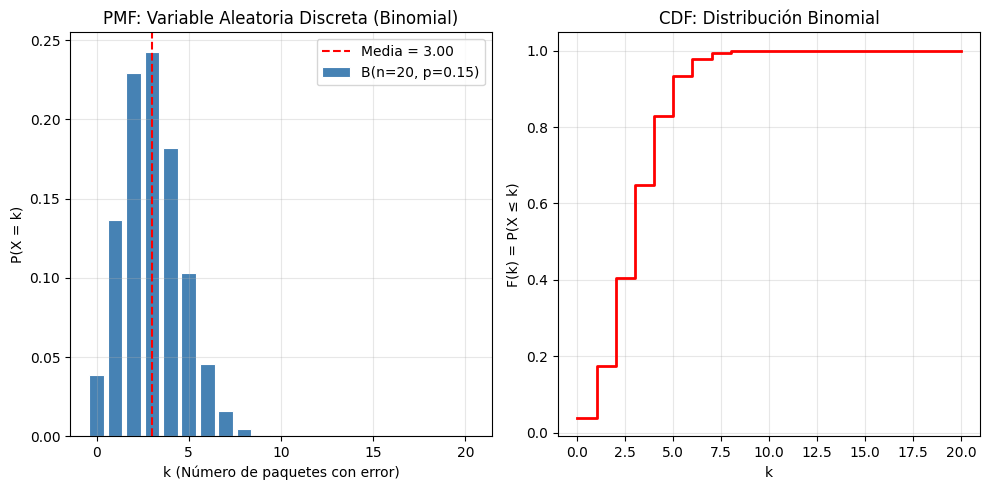

P(X <= 2) = 0.4049 (40.49%)
P(X > 5) = 0.0673 (6.73%)
P(2 <= X <= 6) = 0.8025 (80.25%)

Percentil 95: 6 paquetes
El 95% de los lotes tendrán a lo sumo 6 paquetes con error


In [ ]:
# Sea X la cantidad de paquetes que presentan errores dentro de un conjunto de 20 paquetes transmitidos.
#Cada paquete tiene una probabilidad de error de p=0.15, y se asume que los errores ocurren de forma independiente.
#Por lo tanto, la variable aleatoria X sigue una distribución binomial:
#X∼B(n=20,p=0.15)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros de la distribución binomial
n = 20      # número de ensayos
p = 0.15    # probabilidad de error por paquete

# Crear la distribución
dist_binomial = binom(n=n, p=p)

# Rango de valores posibles
k = np.arange(0, n + 1)

# PMF
pmf_binomial = dist_binomial.pmf(k)

# Visualización
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(k, pmf_binomial, color='steelblue', edgecolor='white', linewidth=0.8,
        label=f'B(n={n}, p={p})')
plt.axvline(dist_binomial.mean(), color='red', linestyle='--',
            label=f'Media = {dist_binomial.mean():.2f}')
plt.xlabel('k (Número de paquetes con error)')
plt.ylabel('P(X = k)')
plt.title('PMF: Variable Aleatoria Discreta (Binomial)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_binomial = dist_binomial.cdf(k)
plt.subplot(1, 2, 2)
plt.step(k, cdf_binomial, 'r-', linewidth=2, where='post')
plt.xlabel('k')
plt.ylabel('F(k) = P(X ≤ k)')
plt.title('CDF: Distribución Binomial')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# a) P(X <= 2)
prob_menor_2 = dist_binomial.cdf(2)
print(f"P(X <= 2) = {prob_menor_2:.4f} ({prob_menor_2*100:.2f}%)")

# b) P(X > 5)
prob_mayor_5 = 1 - dist_binomial.cdf(5)
print(f"P(X > 5) = {prob_mayor_5:.4f} ({prob_mayor_5*100:.2f}%)")

# c) P(2 <= X <= 6)
prob_entre = dist_binomial.cdf(6) - dist_binomial.cdf(1)
print(f"P(2 <= X <= 6) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_binomial.ppf(0.95)
print(f"\nPercentil 95: {int(p95)} paquetes")
print(f"El 95% de los lotes tendrán a lo sumo {int(p95)} paquetes con error")

# 📉 Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática ($E[X]$)


In [ ]:
import numpy as np
from scipy.stats import binom, norm

# 1. Variable Aleatoria Discreta (Distribución Binomial)
n_ensayos, p_exito = 10, 0.4
var_discreta = binom(n_ensayos, p_exito)

# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito}) ---")
print(f"Esperanza E[X]: {esperanza_d}")
print(f"Varianza V[X]: {varianza_d}\n")

# 2. Variable Aleatoria Continua (Distribución Normal)
mu, sigma = 50, 5 # Media y Desviación Estándar
var_continua = norm(loc=mu, scale=sigma)
esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu}, sigma={sigma}) ---")
print(f"Esperanza E[X]: {esperanza_c}")
print(f"Varianza V[X]: {varianza_c}")

--- Variable Discreta (Binomial n=10, p=0.4) ---
Esperanza E[X]: 4.0
Varianza V[X]: 2.3999999999999995

--- Variable Continua (Normal mu=50, sigma=5) ---
Esperanza E[X]: 50.0
Varianza V[X]: 25.0


# 🚀 Tarea 3: Hito del Proyecto - Análisis de Tendencia Central y Dispersión

En esta sección aplicamos los momentos estadísticos calculados computacionalmente sobre el **Dataset Regional** seleccionado para el Proyecto Integrador. El objetivo es caracterizar el comportamiento de las variables clave mediante su centro de masa (media) y su grado de variabilidad (varianza).



--- Análisis del Censo Loja 2022 ---
Media Muestral (Estimador de E[X]): 30338.81 habitantes
Varianza Muestral (Estimador de V[X]): 3511842969.36



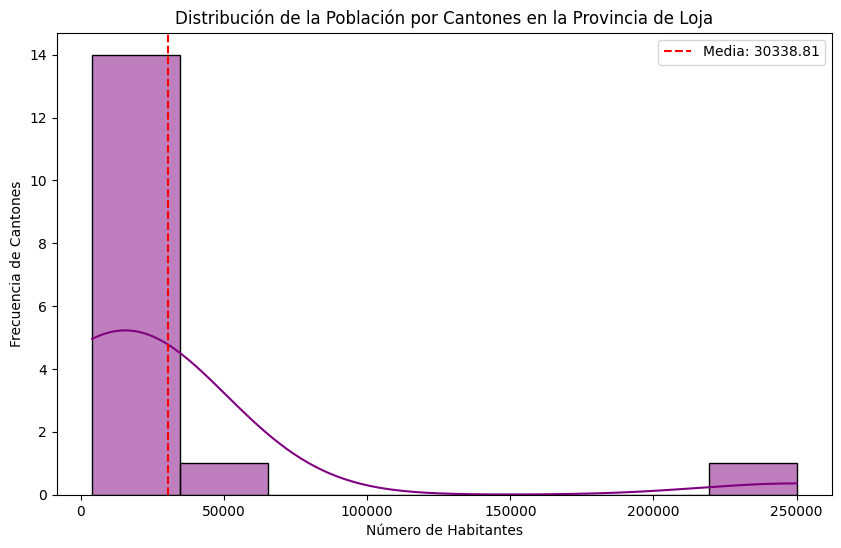

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creación del Dataset basado en los resultados del Censo Loja 2022
data_censo = {
    'Canton': ['Loja', 'Catamayo', 'Saraguro', 'Calvas', 'Paltas', 'Macará',
               'Puyango', 'Zapotillo', 'Celica', 'Espíndola', 'Gonzanamá',
               'Pindal', 'Sozoranga', 'Chaguarpamba', 'Olmedo', 'Quilanga'],
    'Habitantes': [250028, 35240, 29111, 26042, 22841, 18215, 16257, 14571,
                   14379, 14119, 12247, 10409, 6970, 6857, 4164, 3971]
}

df_poblacion = pd.DataFrame(data_censo)

# 2. Identificación de la variable clave (Tarea 3 - Punto 103)
columna_obj = 'Habitantes'

# 3. Cálculo de estadísticos (Tarea 3 - Puntos 104 y 105)
# Usamos ddof=1 para obtener la varianza muestral insesgada
media_muestral = df_poblacion[columna_obj].mean()
varianza_muestral = df_poblacion[columna_obj].var(ddof=1)

print(f"--- Análisis del Censo Loja 2022 ---")
print(f"Media Muestral (Estimador de E[X]): {media_muestral:.2f} habitantes")
print(f"Varianza Muestral (Estimador de V[X]): {varianza_muestral:.2f}\n")

# 4. Visualización para el hito del proyecto (Tarea 3 - Punto 106)
plt.figure(figsize=(10, 6))
sns.histplot(df_poblacion[columna_obj], kde=True, color='purple', bins=8)
plt.axvline(media_muestral, color='red', linestyle='--', label=f'Media: {media_muestral:.2f}')
plt.title('Distribución de la Población por Cantones en la Provincia de Loja')
plt.xlabel('Número de Habitantes')
plt.ylabel('Frecuencia de Cantones')
plt.legend()
plt.show()

#### 📝 **Análisis de Resultados: Provincia de Loja**

A partir del cálculo de los momentos estadísticos sobre la variable poblacional de los 16 cantones, se obtienen las siguientes conclusiones:

---

##### **Media Muestral ($\bar{x}$)**
Representa el número promedio de habitantes si la población estuviera distribuida equitativamente entre los 16 cantones. 🏘️

##### **Varianza Muestral ($s^2$) y Dispersión**
Este valor es sumamente elevado. Esto se debe a que el cantón **Loja (250,028 hab.)** actúa como un valor atípico (**outlier**) muy fuerte en comparación con cantones pequeños como **Quilanga (3,971 hab.)**. 📈


### 📖 Tarea 4: Documentación y Discusión Grupal (ABI)



---

#### **Justificación Estadística: El parámetro `ddof=1`**

En la librería Pandas, el parámetro **ddof** hace referencia a los **Delta Degrees of Freedom** (Grados de Libertad Delta). Por defecto, al usar `.var()`, Pandas emplea `ddof=1`.

Desde el punto de vista estadístico, utilizamos `ddof=1` porque estamos trabajando con una **muestra** de la población de la provincia de Loja (los datos de los cantones) y no con el universo total de datos históricos o proyecciones futuras. Al dividir la suma de los cuadrados de las desviaciones por $n-1$ (donde $n$ es el número de cantones) en lugar de $n$, compensamos el sesgo que surge al estimar la varianza poblacional a partir de una muestra. Esto convierte a la varianza muestral en un **estimador insesgado**, lo que significa que, en promedio, el valor calculado se aproximará mucho mejor a la varianza real de la población.

---

In [ ]:
import itertools

# Definimos una pequeña muestra de cantones de nuestro dataset para el experimento
cantones_muestra = ['Loja', 'Catamayo', 'Saraguro', 'Calvas']

# 1. Generación del Espacio Muestral: Combinaciones de 2 cantones
# Esto es útil para simular experimentos de muestreo sin repetición
espacio_muestral = list(itertools.combinations(cantones_muestra, 2))

print(f"--- Experimento Aleatorio: Selección de pares de cantones ---")
print(f"Cantones disponibles: {cantones_muestra}")
print(f"Tamaño del espacio muestral (nCr): {len(espacio_muestral)}")
print("Espacio Muestral (S):")
for resultado in espacio_muestral:
    print(f" - {resultado}")

# 2. Ejemplo adicional con Producto Cartesiano (itertools.product)
# Simulamos el espacio muestral de elegir un cantón y un tipo de área (Urbano/Rural)
areas = ['Urbano', 'Rural']
espacio_completo = list(itertools.product(cantones_muestra, areas))

print(f"\n--- Producto Cartesiano: Cantón y Área de Residencia ---")
print(f"Total de resultados posibles: {len(espacio_completo)}")
print(f"Primeros 4 resultados: {espacio_completo[:4]}")

--- Experimento Aleatorio: Selección de pares de cantones ---
Cantones disponibles: ['Loja', 'Catamayo', 'Saraguro', 'Calvas']
Tamaño del espacio muestral (nCr): 6
Espacio Muestral (S):
 - ('Loja', 'Catamayo')
 - ('Loja', 'Saraguro')
 - ('Loja', 'Calvas')
 - ('Catamayo', 'Saraguro')
 - ('Catamayo', 'Calvas')
 - ('Saraguro', 'Calvas')

--- Producto Cartesiano: Cantón y Área de Residencia ---
Total de resultados posibles: 8
Primeros 4 resultados: [('Loja', 'Urbano'), ('Loja', 'Rural'), ('Catamayo', 'Urbano'), ('Catamayo', 'Rural')]


## 📝 **PREGUNTAS DE CONTROL - Práctica Nro. 004**

---

###### 📊 **1.- ¿Cuál es la diferencia matemática y conceptual entre la esperanza matemática teórica calculada a partir de un modelo de probabilidad (ej. `binom.stats()`) y la media muestral calculada de un DataFrame de pandas?**

**La esperanza matemática teórica** se calcula a partir de un modelo de probabilidad y representa el valor promedio esperado de una variable aleatoria si el experimento se repite muchas veces. Es un valor **fijo** definido por la distribución. En cambio, **la media muestral** se calcula a partir de datos reales (por ejemplo, en un DataFrame de pandas) y puede **variar** dependiendo de la muestra utilizada. **La diferencia principal** es que la esperanza es **teórica** (modelo ideal ), mientras que la media muestral es **empírica** (datos observados ).



---

###### 📐 **2.- Demuestre teóricamente, utilizando las propiedades de la esperanza, por qué la varianza se puede reescribir como $V[X] = E[X^2] - (E[X])^2$**

La varianza mide qué tan lejos están los datos de la media. Se define como:

$$Var(X) = E[(X - \mu)^2]$$

donde $\mu$ es la media. Si desarrollamos el cuadrado:

$$(X - \mu)^2 = X^2 - 2X\mu + \mu^2$$

Entonces:
$$Var(X) = E[X^2 - 2X\mu + \mu^2]$$

Ahora usamos una propiedad importante: la esperanza separa términos:
$$Var(X) = E[X^2] - 2\mu E[X] + \mu^2$$

Sabemos que $E[X] = \mu$, entonces:
$$Var(X) = E[X^2] - 2\mu^2 + \mu^2$$

Simplificando:
$$Var(X) = E[X^2] - \mu^2$$

Y como $\mu = E[X]$:
$$Var(X) = E[X^2] - (E[X])^2$$

✔ **En pocas palabras:** La varianza es igual a "el promedio de los cuadrados" menos "el cuadrado del promedio".



---

###### 📍 **3.- Si la varianza calculada en su variable regional es inusualmente alta, ¿qué implicaciones prácticas tiene esto sobre la confiabilidad de la media como predictor del comportamiento de esos datos en la región de Loja?**

Si la varianza es muy alta, significa que los datos están muy dispersos. En la práctica, esto implica que la media **no es un buen predictor** del comportamiento de los datos, ya que existen valores muy diferentes entre sí. Puede haber valores extremos (**outliers**) que distorsionan el promedio. En este caso, es recomendable usar otras medidas como la mediana o analizar la distribución completa.




---

###### ⚙️ **4.- Revise el parámetro `ddof` de la función `var()` en Pandas. ¿Qué ocurre con el estimador de la varianza si establecemos `ddof=0` y en qué escenario específico de población poblacional esto sería matemáticamente correcto?**

En pandas, `var()` usa por defecto `ddof=1`, lo que calcula la varianza muestral (dividiendo entre $n-1$). Si usamos `ddof=0`, se calcula la varianza poblacional (dividiendo entre $n$).

Esto es correcto únicamente cuando se tiene toda la **población completa** y no una muestra. Por ejemplo, si tienes todos los datos de una región y no solo una parte.



---

###### 🔍 **5.- Observe el histograma generado en la Tarea 3. ¿De qué manera el cálculo combinado de la esperanza matemática (media) y la varianza apoyan en la identificación estadística de valores atípicos (outliers) para la posterior limpieza de su Proyecto Integrador?**


La media nos muestra el centro de los datos y la varianza su dispersión. Cuando existen valores muy alejados de la media, como en este caso, estos aumentan la varianza y se identifican como outliers, lo que permite mejorar la limpieza y calidad del análisis de datos